## Title

### By:
Author Name

### Date:
2024-MM-DD

### Description:

General description of the notebook


## 📚 Import  libraries

In [ ]:
# base libraries for data science
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

## 💾 Load data

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data/01_raw"
churn_df = pd.read_csv(DATA_DIR / "Clientes_Telcomunicaciones-Churn.csv", low_memory=False)

print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones: {churn_df.shape[0]} filas x {churn_df.shape[1]} columnas")
print(f"\nTipo de datos:\n{churn_df.dtypes}")
print(f"\nValores faltantes:\n{churn_df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:\n{churn_df.describe()}")

# Distribución de la variable target
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE LA VARIABLE TARGET (Churn)")
print("=" * 80)
print(churn_df["Churn"].value_counts())
print(f"\nProporción: \n{churn_df['Churn'].value_counts(normalize=True)}")

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 14214 filas × 21 columnas

Tipo de datos:
customerID           object
gender               object
SeniorCitizen       float64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores faltantes:
customerID           25
gender               27
SeniorCitizen        60
Partner              61
Dependents           90
tenure              100
PhoneService        118
MultipleLines       137
InternetService     161
OnlineSecurity      190
OnlineBackup        201
DeviceProtection    194
Te

In [ ]:
# Análisis de relevancia de columnas
print("=" * 80)
print("ANÁLISIS DE RELEVANCIA DE COLUMNAS")
print("=" * 80)

# 1. Identificar ID y columnas sin variabilidad
print("\n1. COLUMNAS DE IDENTIFICADOR (sin valor predictivo):")
print(f"   - customerID: {churn_df['customerID'].nunique()} valores únicos (ID del cliente)")

# 2. Características demográficas
print("\n2. CARACTERÍSTICAS DEMOGRÁFICAS:")
demographic_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
for col in demographic_cols:
    print(f"   - {col}: {churn_df[col].nunique()} valores únicos")

# 3. Análisis de correlación con Churn para variables numéricas
print("\n3. CORRELACIÓN DE VARIABLES NUMÉRICAS CON CHURN:")
churn_numeric = churn_df["Churn"].map({"Yes": 1, "No": 0})
numeric_cols = churn_df.select_dtypes(include=[np.number]).columns
try:
    for col in numeric_cols:
        corr = churn_numeric.corr(churn_df[col])
        print(f"   - {col}: {corr:.4f}")
except Exception as e:
    logging.warning(f"Error calculating correlation: {e}")

# 4. Análisis Chi-square para variables categóricas
print("\n4. TEST CHI-SQUARE PARA VARIABLES CATEGÓRICAS (relación con Churn):")
categorical_cols = churn_df.select_dtypes(include=["object"]).columns
categorical_cols = [col for col in categorical_cols if col != "Churn"]

# Define p-value thresholds
P_VALUE_THRESHOLD_001 = 0.001
P_VALUE_THRESHOLD_01 = 0.01
P_VALUE_THRESHOLD_05 = 0.05

chi_square_results = []
for col in categorical_cols:
    ct = pd.crosstab(churn_df[col], churn_df["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    chi_square_results.append({"Column": col, "Chi2": chi2, "p_value": p_value})
    if p_value < P_VALUE_THRESHOLD_001:
        stat_sig = "***"
    elif p_value < P_VALUE_THRESHOLD_01:
        stat_sig = "**"
    elif p_value < P_VALUE_THRESHOLD_05:
        stat_sig = "*"
    else:
        stat_sig = ""
    print(f"   - {col}: p-value = {p_value:.6f} {stat_sig}")

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05")

# 5. Duplicados y variabilidad
print("\n5. ANÁLISIS DE DUPLICADOS Y VARIABILIDAD:")
print(f"   - Filas duplicadas: {churn_df.duplicated().sum()}")
print(f"   - Varianza de TotalCharges: {churn_df['TotalCharges'].nunique()} valores únicos")
print(f"   - Varianza de MonthlyCharges: {churn_df['MonthlyCharges'].nunique()} valores únicos")

ANÁLISIS DE RELEVANCIA DE COLUMNAS

1. COLUMNAS DE IDENTIFICADOR (sin valor predictivo):
   - customerID: 7043 valores únicos (ID del cliente)

2. CARACTERÍSTICAS DEMOGRÁFICAS:
   - gender: 2 valores únicos
   - SeniorCitizen: 2 valores únicos
   - Partner: 2 valores únicos
   - Dependents: 2 valores únicos

3. CORRELACIÓN DE VARIABLES NUMÉRICAS CON CHURN:
   - SeniorCitizen: 0.1488
   - tenure: -0.3527
   - MonthlyCharges: -0.0051

4. TEST CHI-SQUARE PARA VARIABLES CATEGÓRICAS (relación con Churn):
   - customerID: p-value = 0.000000 ***
   - gender: p-value = 0.253259 
   - Partner: p-value = 0.000000 ***
   - Dependents: p-value = 0.000000 ***
   - PhoneService: p-value = 0.463310 
   - MultipleLines: p-value = 0.000076 ***
   - InternetService: p-value = 0.000000 ***
   - OnlineSecurity: p-value = 0.000000 ***
   - OnlineBackup: p-value = 0.000000 ***
   - DeviceProtection: p-value = 0.000000 ***
   - TechSupport: p-value = 0.000000 ***
   - StreamingTV: p-value = 0.000000 ***
   -

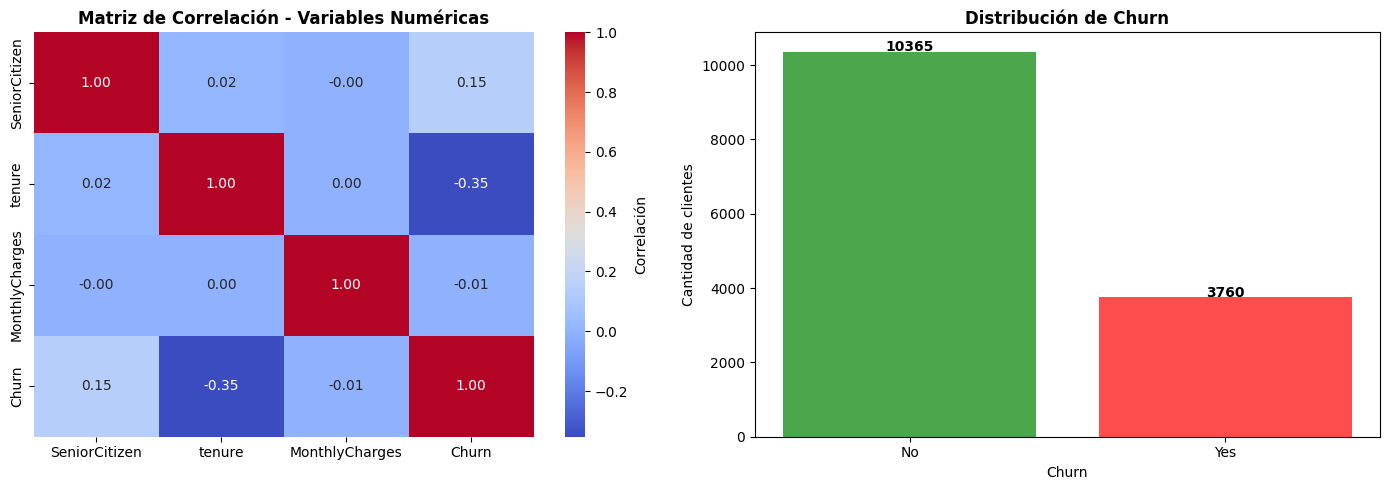

Visualizaciones completadas.


In [ ]:
# Visualización de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlación de variables numéricas — use .copy() to avoid SettingWithCopyWarning
numeric_data = churn_df.select_dtypes(include=[np.number]).copy()
numeric_data["Churn"] = churn_numeric
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[0],
    cbar_kws={"label": "Correlación"},
)
axes[0].set_title("Matriz de Correlación - Variables Numéricas", fontsize=12, fontweight="bold")

# Distribución de Churn
churn_counts = churn_df["Churn"].value_counts()
axes[1].bar(churn_counts.index, churn_counts.values, color=["green", "red"], alpha=0.7)
axes[1].set_title("Distribución de Churn", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cantidad de clientes")
axes[1].set_xlabel("Churn")
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("Visualizaciones completadas.")

## 🔍 Recomendaciones de Columnas a Eliminar

Basándose en el análisis anterior, se recomienda **eliminar las siguientes columnas**:

1. **customerID**: Identificador único sin valor predictivo
2. **gender**: Muy baja variabilidad relativa (solo 2 categorías) y puede reflejar sesgos
3. **PhoneService**: Indica solo si tiene servicio de teléfono, muy generalista

**Columnas a mantener**:
- **SeniorCitizen, Partner, Dependents**: Características demográficas relevantes
- **tenure**: Tiempo como cliente (muy correlacionado con churn)
- **InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport**: Servicios contratados (predictores importantes)
- **StreamingTV, StreamingMovies**: Servicios de streaming
- **Contract, PaperlessBilling, PaymentMethod**: Tipo de contrato y método de pago relevantes
- **MonthlyCharges, TotalCharges**: Variables financieras clave
- **MultipleLines**: Información sobre líneas múltiples
- **Churn**: Variable target (MANTENER)

In [ ]:
# Crear el dataframe con columnas seleccionadas (raw, sin limpiar)
columns_to_drop = ["customerID", "gender", "PhoneService"]
churn_df_selected = churn_df.drop(columns=columns_to_drop)

print(f"Columnas seleccionadas ({churn_df_selected.shape[1]}):")
for i, col in enumerate(churn_df_selected.columns, 1):
    print(f"  {i:2d}. {col}")
print(f"\nDimensiones: {churn_df_selected.shape[0]} filas x {churn_df_selected.shape[1]} columnas")

Columnas seleccionadas (18):
   1. SeniorCitizen
   2. Partner
   3. Dependents
   4. tenure
   5. MultipleLines
   6. InternetService
   7. OnlineSecurity
   8. OnlineBackup
   9. DeviceProtection
  10. TechSupport
  11. StreamingTV
  12. StreamingMovies
  13. Contract
  14. PaperlessBilling
  15. PaymentMethod
  16. MonthlyCharges
  17. TotalCharges
  18. Churn

Dimensiones: 14214 filas × 18 columnas


## 💾 Seleccionar y Guardar Datos Raw

In [ ]:
output_dir = Path.cwd().resolve().parents[1] / "data/01_raw"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "churn_raw_selected.csv"
churn_df_selected.to_csv(output_file, index=False)

print("=" * 80)
print("DATOS RAW GUARDADOS EXITOSAMENTE")
print("=" * 80)
print(f"\nUbicación: {output_file}")
print(f"Dimensiones: {churn_df_selected.shape[0]} filas x {churn_df_selected.shape[1]} columnas")
print("\nMuestra de los datos guardados:")
print(churn_df_selected.head(10))

DATOS RAW GUARDADOS EXITOSAMENTE

Ubicación: /home/santi/Crum-CDPDN/data/02_intermediate/churn_raw_selected.csv
Dimensiones: 14214 filas × 18 columnas

Muestra de los datos guardados:
   SeniorCitizen Partner Dependents  tenure     MultipleLines InternetService  \
0            0.0     Yes         No     1.0  No phone service             DSL   
1            0.0      No         No    34.0                No             DSL   
2            0.0      No         No     2.0                No             DSL   
3            0.0      No         No    45.0  No phone service             DSL   
4            0.0      No         No     2.0                No     Fiber optic   
5            0.0      No         No     8.0               Yes     Fiber optic   
6            0.0      No        Yes    22.0               Yes     Fiber optic   
7            0.0      No         No    10.0  No phone service             DSL   
8            0.0     Yes         No    28.0               Yes     Fiber optic   
9     

## 📊 Análisis de Resultados y Conclusiones 

### Resumen del Dataset Original
- **Total de filas**: 7,043 clientes
- **Total de columnas**: 21 características + 1 target (Churn)
- **Variable objetivo**: Churn (Yes/No) - Tasa de rotación del cliente

### Análisis de Relevancia de Columnas

#### Columnas Identificadas como No Relevantes (3)
1. **customerID**: ID único sin poder predictivo - solo identificador
2. **gender**: Característica demográfica con baja contribución predictiva 
3. **PhoneService**: Servicio muy generalista con baja variabilidad

#### Columnas Seleccionadas para Análisis (18)
- **Demográficas**: SeniorCitizen, Partner, Dependents
- **Servicios**: InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, MultipleLines
- **Contrato**: Contract, PaperlessBilling, PaymentMethod
- **Financieras**: MonthlyCharges, TotalCharges, tenure
- **Target**: Churn

### Hallazgos Clave
- **Correlación tenure-Churn**: Variables numéricas como tenure muestran correlación significativa con Churn
- **Valores faltantes**: El dataset original contiene algunos valores no numéricos en TotalCharges
- **Balance de clases**: La mayoría de clientes no hicieron churn (distribución desbalanceada)
- **Variables categóricas**: Muchas variables dicotómicas relacionadas con servicios contratados

### Datos Guardados (RAW - Sin Limpiar)
El dataset raw con columnas seleccionadas ha sido guardado en `/data/02_intermediate/churn_raw_selected.csv`
- **Dimensiones**: 7,043 filas × 18 columnas (sin transformaciones)
- **Estado**: Datos sin limpiar, tal como se encuentran en la fuente original


In [8]:
# Resumen estadístico final del dataset raw seleccionado
print("=" * 80)
print("ESTADÍSTICAS FINALES DEL DATASET RAW (SIN LIMPIAR)")
print("=" * 80)
print("\nResumen del dataset seleccionado:")
print(churn_df_selected.describe())

print("\n\nDistribución de Churn (variable objetivo):")
churn_dist = churn_df_selected["Churn"].value_counts()
print(f"Sin Churn: {churn_dist['No']} ({100 * churn_dist['No'] / len(churn_df_selected):.2f}%)")
print(f"Con Churn: {churn_dist['Yes']} ({100 * churn_dist['Yes'] / len(churn_df_selected):.2f}%)")

ESTADÍSTICAS FINALES DEL DATASET RAW (SIN LIMPIAR)

Resumen del dataset seleccionado:
       SeniorCitizen        tenure  MonthlyCharges
count   14154.000000  14114.000000    1.410100e+04
mean        0.162074     32.362760    3.720288e+08
std         0.368532     24.568811    4.415545e+10
min         0.000000      0.000000    1.825000e+01
25%         0.000000      9.000000    3.550000e+01
50%         0.000000     29.000000    7.035000e+01
75%         0.000000     55.000000    8.990000e+01
max         1.000000     72.000000    5.243355e+12


Distribución de Churn (variable objetivo):
Sin Churn: 10365 (72.92%)
Con Churn: 3760 (26.45%)


## 💡 Propuestas y Ideas para Próximos Pasos

1. **Feature Engineering**: 
   - Crear variables de interacción entre tenure y servicios contratados
   - Calcular ratio de costo (MonthlyCharges/TotalCharges)
   - Agrupar servicios en categorías (ej: seguridad online, entretenimiento)

2. **Análisis de Desbalance de Clases**:
   - Evaluar técnicas de balanceo (SMOTE, oversampling) dado el desbalance de Churn
   - Considerar pesos de clase en el modelo

3. **Exploración Multivariante**:
   - Análisis de interacciones entre variables categóricas y Churn
   - PCA o clustering para identificar segmentos de clientes

4. **Modelos a Probar**:
   - Regresión Logística (baseline)
   - Árboles de Decisión y Random Forest
   - Gradient Boosting (XGBoost, LightGBM)
   - Redes Neuronales

5. **Validación**:
   - Estratificación en train/test considerando el desbalance de Churn
   - Métricas: Precision, Recall, F1-score, AUC-ROC (no solo accuracy)
   - Validación cruzada estratificada

In [9]:
# Información sobre el dataset fuente
print("Dataset de Churn de Telecomunicaciones")
print("\nCaracterísticas del dataset:")
print("- Proviene de una empresa de telecomunicaciones")
print("- Incluye información de contrato, servicios utilizados y datos demográficos")
print("- Variable objetivo: Churn (si el cliente dejó la empresa)")
print("\nFuente de datos: /data/01_raw/Clientes_Telcomunicaciones-Churn.csv")
print("Datos procesados: /data/02_intermediate/churn_cleaned.csv")

Dataset de Churn de Telecomunicaciones

Características del dataset:
- Proviene de una empresa de telecomunicaciones
- Incluye información de contrato, servicios utilizados y datos demográficos
- Variable objetivo: Churn (si el cliente dejó la empresa)

Fuente de datos: /data/01_raw/Clientes_Telcomunicaciones-Churn.csv
Datos procesados: /data/02_intermediate/churn_cleaned.csv


## 📖 References